#**Importing Libararies**

In [ ]:
# Core Libraries
import kagglehub
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

# Settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

print("Libraries loaded successfully.")

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Libraries loaded successfully.


#**Data Collection**

In [ ]:
# Reading Dataset
df = pd.read_csv(path + "/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Dataset dimensions
print(df.shape)

# Data structure overview
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


#**Data Cleaning & Preprocessing**

###Missing Data Analysis

In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


###Finding & Removing Constant Columns

In [ ]:
df.nunique().sort_values()

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [ ]:
drop_cols=[
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]
df=df.drop(drop_cols,axis=1)
print(f"\nNew Dataset Shape after cleaning: {df.shape}")


New Dataset Shape after cleaning: (1470, 31)


###Data Transformation

In [ ]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical Columns:", cat_cols)
df[cat_cols].head()

Categorical Columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Yes,Travel_Rarely,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,No,Travel_Frequently,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Yes,Travel_Rarely,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,No,Travel_Frequently,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,No,Travel_Rarely,Research & Development,Medical,Male,Laboratory Technician,Married,No


In [ ]:
cat_cols.remove("Attrition")

# One hot encoding.
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

# Encode target variable (Yes=1, No=0)
df_encoded["Attrition"] = df_encoded["Attrition"].map({"No": 0, "Yes": 1})
df_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,0,1,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,0,1,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0


#**Exploratory Data Analysis**

###Statistical Analysis

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


###Visual Analysis

######Univariate Analysis

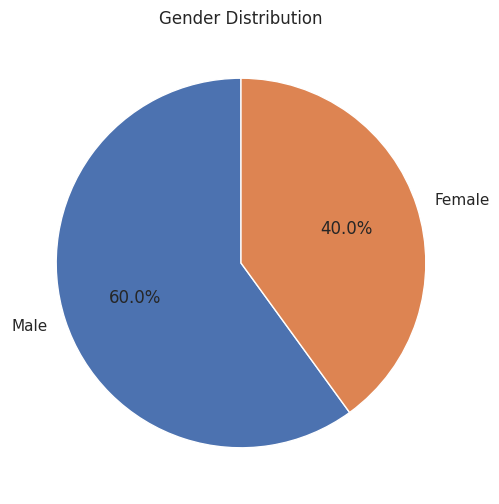

In [ ]:
plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

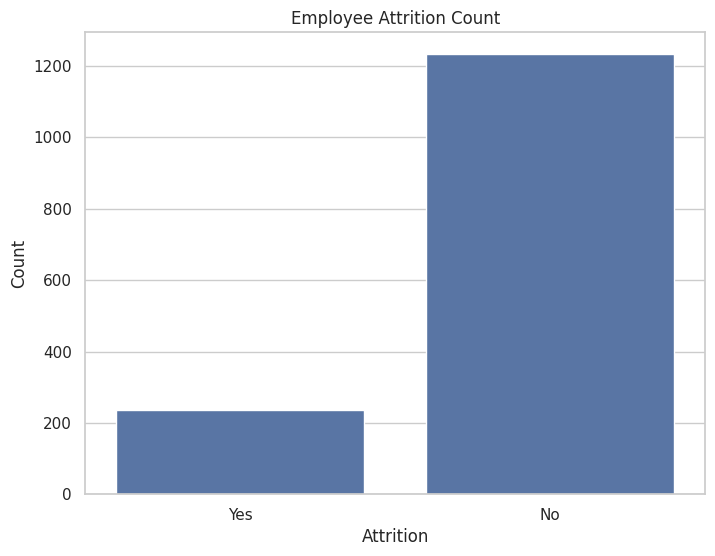

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Count')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()

######Bivariate Analysis

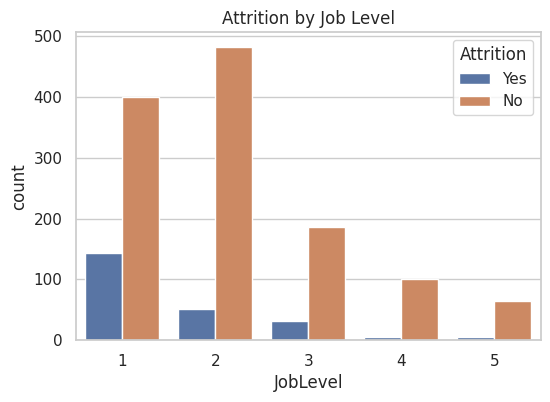

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="JobLevel", hue="Attrition", data=df)
plt.title("Attrition by Job Level")
plt.show()

**Interpretation: Job Level and Attrition**
The distribution of attrition across job levels reveals several insights:
*   **Highest Attrition Count:** Job Level 1 exhibits the highest number of employees leaving, approximately 145 individuals.
*   **Lowest Attrition Count:** Job Levels 4 and 5 show the lowest attrition, each with fewer than 10 employees leaving.
*   **Highest Retention:** Job Level 2 has the highest number of employees remaining ("No" category), around 480 individuals.
*   **Overall Trend:** As job level increases from 1 to 5, both total employee count and attrition count decrease, indicating that higher hierarchical positions are associated with lower turnover.

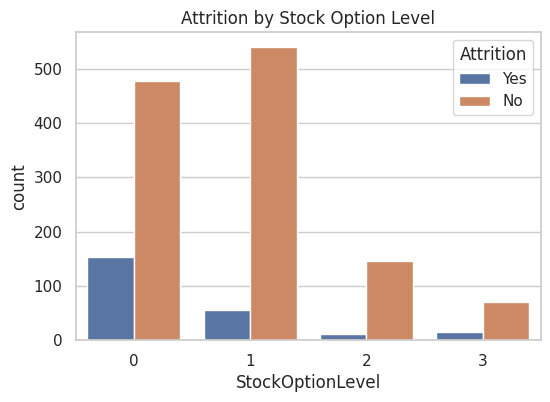

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="StockOptionLevel", hue="Attrition", data=df)
plt.title("Attrition by Stock Option Level")
plt.show()

Moving from Level 0 to Level 1, the number of employees leaving decreases sharply. These observations suggest that even modest equity-based incentives (e.g., Stock Option Level 1) are associated with increased retention, highlighting the importance of long-term financial incentives in mitigating attrition.

###Feature Correlation

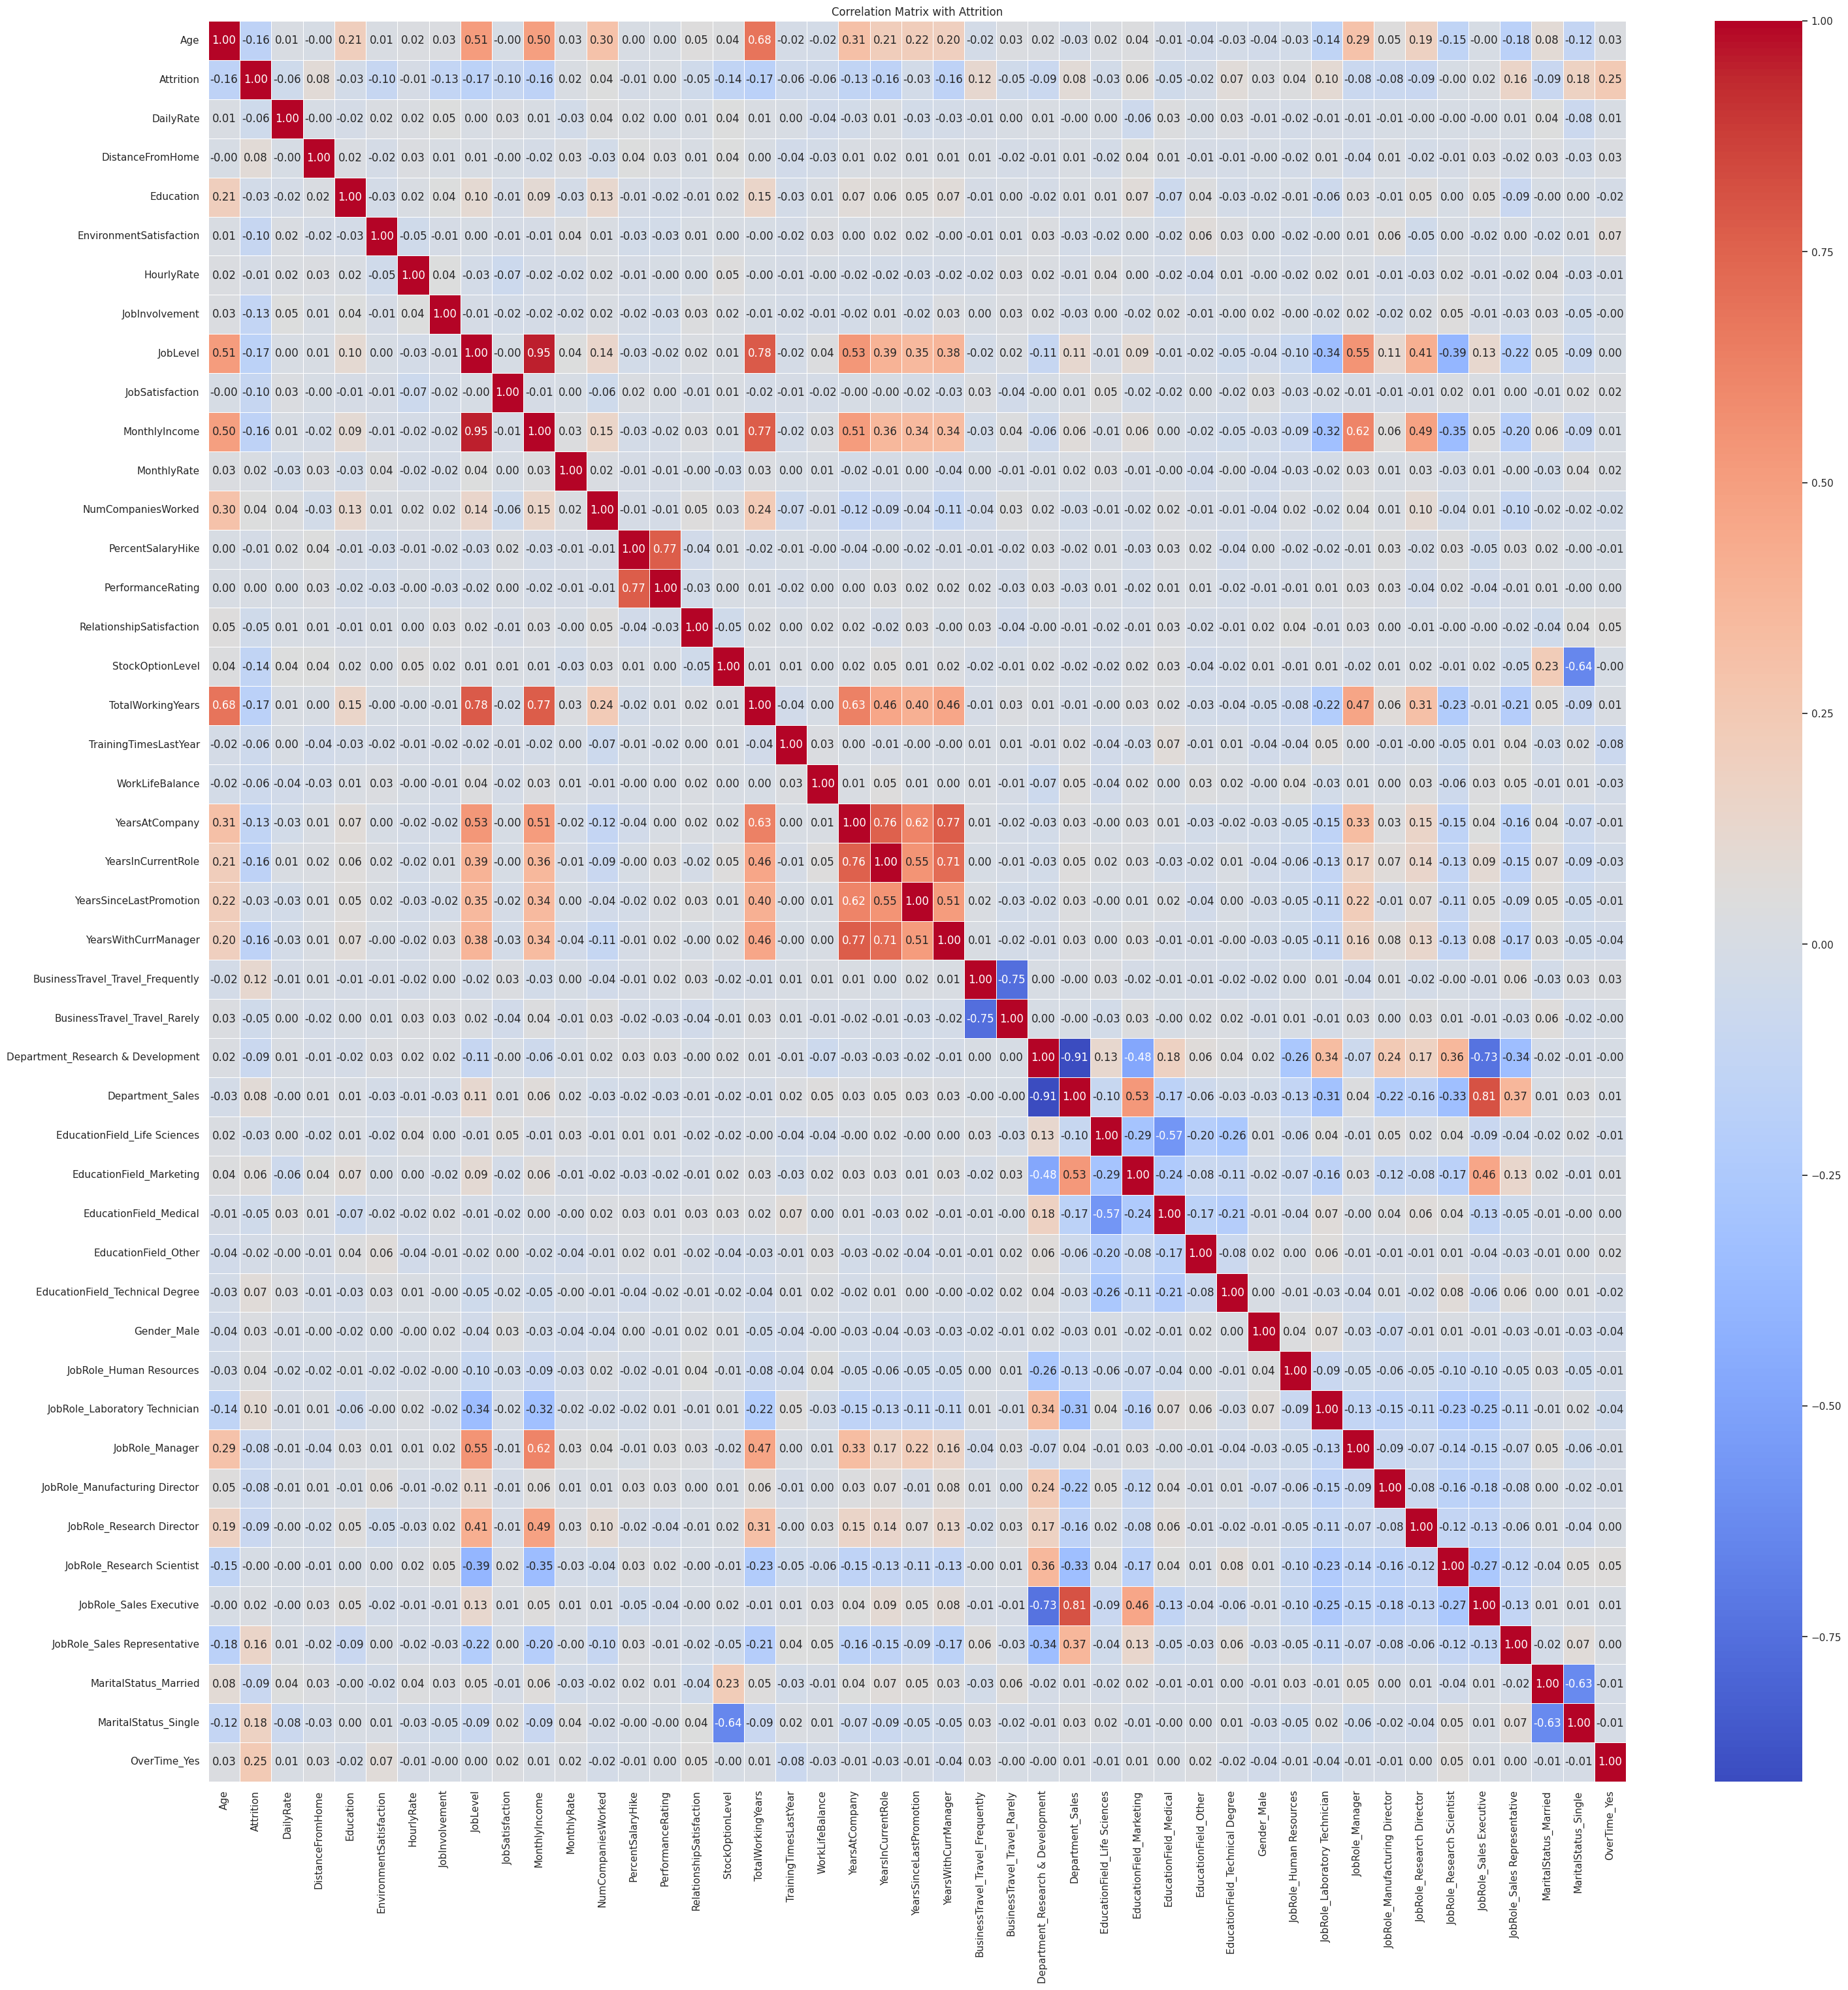

In [ ]:
df_corr = df_encoded.copy()
corr_matrix = df_corr.corr()
plt.figure(figsize=(35,35))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix with Attrition")
plt.show()

In [ ]:
print("Top factors positvely correlated(What drives people away) with Attrition:")
print(corr_matrix['Attrition'].sort_values(ascending=False).head(6))
print()
print("Top factors negatively correlated(What keeps people) with Attrition:")
print(corr_matrix['Attrition'].sort_values(ascending=True).head(10))

Top factors positvely correlated(What drives people away) with Attrition:
Attrition                           1.000000
OverTime_Yes                        0.246118
MaritalStatus_Single                0.175419
JobRole_Sales Representative        0.157234
BusinessTravel_Travel_Frequently    0.115143
JobRole_Laboratory Technician       0.098290
Name: Attrition, dtype: float64

Top factors negatively correlated(What keeps people) with Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition, dtype: float64


#**Model Training & Evaluation**

In [ ]:
x=df_encoded.drop('Attrition',axis=1)
y=df_encoded['Attrition']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

print(x_train.shape)
print(x_test.shape)

(1176, 44)
(294, 44)


In [ ]:
log_model=LogisticRegression(random_state=42)
log_model.fit(x_train,y_train)

log_preds=log_model.predict(x_test)
log_probs=log_model.predict_proba(x_test)[:,1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))
print("ROC-AUC Score:", roc_auc_score(y_test, log_probs))
print(classification_report(y_test, log_preds))

Logistic Regression Accuracy: 0.8605442176870748
ROC-AUC Score: 0.8079076578516668
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [ ]:
rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(x_train,y_train)

rf_preds=rf.predict(x_test)
rf_probs=rf.predict_proba(x_test)[:,1]

print('Random Forest Accuracy:',accuracy_score(y_test,rf_preds))
print('ROC-AUC Score:',roc_auc_score(y_test,rf_probs))
print(classification_report(y_test,rf_preds))

Random Forest Accuracy: 0.826530612244898
ROC-AUC Score: 0.8040313549832028
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.33      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.59      0.53      0.52       294
weighted avg       0.77      0.83      0.78       294



In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, log_preds),
        accuracy_score(y_test, rf_preds)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_probs),
        roc_auc_score(y_test, rf_probs)
    ]
})
results

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.860544,0.807908
1,Random Forest,0.826531,0.804031
